In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
import numpy as np



In [4]:
my_data = pd.read_csv('/content/heart_failure.csv')

In [5]:
print(my_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None


In [6]:
from collections import Counter
print('Classes and number of values in the dataset',Counter(my_data['DEATH_EVENT']))

Classes and number of values in the dataset Counter({0: 203, 1: 96})


In [7]:
y = my_data["DEATH_EVENT"]

In [8]:
x = my_data[['age','anaemia','creatinine_phosphokinase','diabetes','ejection_fraction','high_blood_pressure','platelets','serum_creatinine','serum_sodium','sex','smoking','time']]

In [9]:
my_features = x

In [10]:
x  = pd.get_dummies(my_features)


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [12]:
from sklearn.preprocessing import StandardScaler
ct = ColumnTransformer([("numeric", StandardScaler(), ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time'])])

In [13]:
X_train = ct.fit_transform(X_train)

In [14]:
ct.n_features_in_ = 7

In [15]:
X_train = pd.DataFrame(X_train)

In [16]:
X_test = ct.transform(X_test)

In [17]:
le = LabelEncoder()


In [18]:
Y_train  = le.fit_transform(Y_train.astype(str))

In [19]:
Y_test_labels = le.transform(Y_test.astype(str))

In [20]:
from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(Y_train)


In [21]:
from tensorflow.keras.models import Sequential
model = Sequential()

In [22]:
model.add(InputLayer(input_shape=(X_train.shape[1],)))

In [23]:
from tensorflow.keras.layers import Dense
model.add(Dense(12, activation='relu'))


In [24]:
model.add(Dense(2, activation='softmax'))

In [25]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [26]:
model.fit(X_train, Y_train, epochs = 50, batch_size = 2, verbose=1)

Epoch 1/50
105/105 [==============================] - 1s 2ms/step - loss: 0.7153 - accuracy: 0.5837
Epoch 2/50
105/105 [==============================] - 0s 2ms/step - loss: 0.6101 - accuracy: 0.6842
Epoch 3/50
105/105 [==============================] - 0s 2ms/step - loss: 0.5448 - accuracy: 0.7368
Epoch 4/50
105/105 [==============================] - 0s 2ms/step - loss: 0.5013 - accuracy: 0.7656
Epoch 5/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4674 - accuracy: 0.7895
Epoch 6/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4423 - accuracy: 0.8038
Epoch 7/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4236 - accuracy: 0.8086
Epoch 8/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4085 - accuracy: 0.8182
Epoch 9/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3976 - accuracy: 0.8230
Epoch 10/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3891 - accuracy: 0.8182

In [27]:
y_ = model.predict(X_test, verbose=0)


In [28]:
import numpy as np

y_estimate = np.array([[0.1, 0.2, 0.3]])
y_estimate = np.argmax(y_estimate, axis = 1)

print(y_estimate)

[2]


In [29]:
import numpy as np

y_true = np.array([[0.1, 0.2, 0.3]])
y_true = np.argmax(y_true, axis = 1)

print(y_estimate)

[2]


In [30]:
print(Y_test.shape, y_.shape)

(90,) (90, 2)


In [31]:
print(classification_report(Y_test, y_.argmax(1)))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88        62
           1       0.83      0.54      0.65        28

    accuracy                           0.82        90
   macro avg       0.83      0.74      0.77        90
weighted avg       0.82      0.82      0.81        90



In [33]:
import matplotlib.pyplot as plt

3/3 [==============================] - 0s 3ms/step


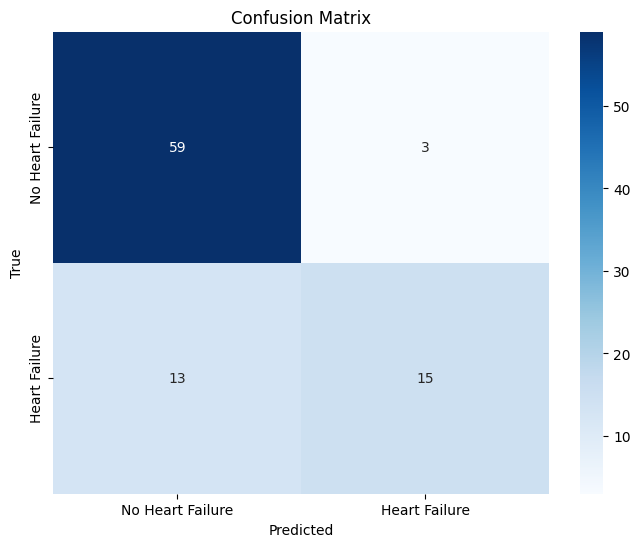

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Failure', 'Heart Failure'],
            yticklabels=['No Heart Failure', 'Heart Failure'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Epoch 1/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3060 - accuracy: 0.8565
Epoch 2/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3046 - accuracy: 0.8517
Epoch 3/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3022 - accuracy: 0.8517
Epoch 4/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3018 - accuracy: 0.8565
Epoch 5/50
105/105 [==============================] - 0s 2ms/step - loss: 0.3012 - accuracy: 0.8469
Epoch 6/50
105/105 [==============================] - 0s 3ms/step - loss: 0.2992 - accuracy: 0.8612
Epoch 7/50
105/105 [==============================] - 0s 4ms/step - loss: 0.2991 - accuracy: 0.8517
Epoch 8/50
105/105 [==============================] - 1s 5ms/step - loss: 0.2974 - accuracy: 0.8612
Epoch 9/50
105/105 [==============================] - 0s 4ms/step - loss: 0.2975 - accuracy: 0.8469
Epoch 10/50
105/105 [==============================] - 0s 4ms/step - loss: 0.2949 - accuracy: 0.8565

KeyError: 'val_accuracy'

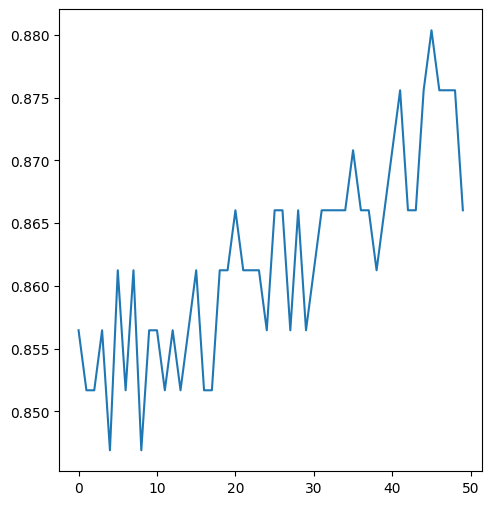

In [37]:
import matplotlib.pyplot as plt

history = model.fit(X_train, Y_train, epochs=50, batch_size=2, verbose=1)

# Plot training history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


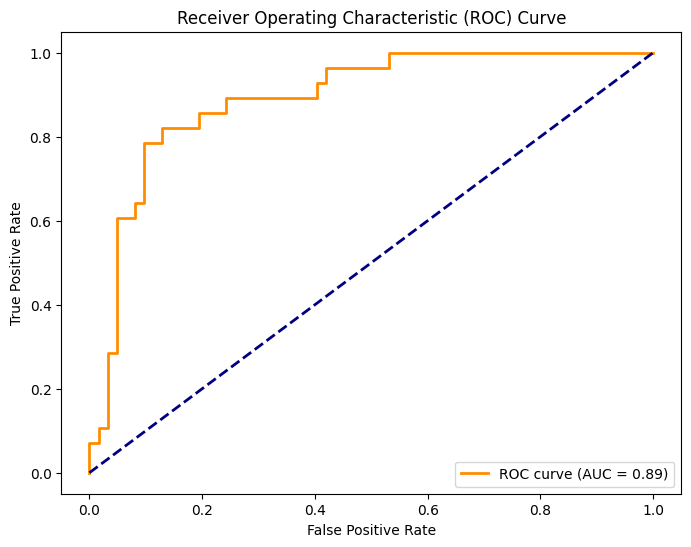

In [38]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(Y_test, y_pred[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
